Import Libraries and Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns

df = pd.read_csv('/Users/phoebeyang/Downloads/data_jobs.csv')
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
import ast

df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str)
    else x if isinstance(x, list)
    else []
)

Filter USA data

In [ ]:
df_US = df[df['job_country'] == 'United States']


Explode Skills Column

In [7]:
df_US_skills = df_US.explode('job_skills')
df_US_skills[['job_title_short', 'job_skills']]

,job_title_short,job_skills
0,Senior Data Engineer,NaN
3,Data Engineer,python
3,Data Engineer,c++
3,Data Engineer,java
3,Data Engineer,matlab
...,...,...
785692,Data Scientist,r
785703,Data Analyst,NaN
785705,Data Analyst,sql
785705,Data Analyst,python


Count Skills per Job Title
Groups DataFrame by job_skills and job_title_short, counting the occurrences of each skill within each job title. Then resets the index of the Series to turn it back into a DataFrame and renames the series holding the count to 'count'. The final DataFrame, df_skills_count, shows the frequency of each skill with each job title.

In [8]:
df_US_skills_count = df_US_skills.groupby(['job_title_short', 'job_skills']).size()
df_US_skills_count = df_US_skills_count.reset_index(name='skill_count')
df_US_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_US_skills_count


,job_title_short,job_skills,skill_count
886,Data Scientist,python,42379
472,Data Analyst,sql,34452
921,Data Scientist,sql,30034
351,Data Analyst,excel,27519
890,Data Scientist,r,26022
...,...,...,...
1313,Senior Data Engineer,asp.net core,1
228,Cloud Engineer,ms access,1
1020,Machine Learning Engineer,graphql,1
1582,Senior Data Scientist,mariadb,1


Create List of Top 3 Skills
Focus on Data Analyst, Data Engineer and Data Scientist

In [15]:
job_titles = df_US_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles)[:3]
job_titles


['Business Analyst', 'Cloud Engineer', 'Data Analyst']

Plot the Top 3 Skills

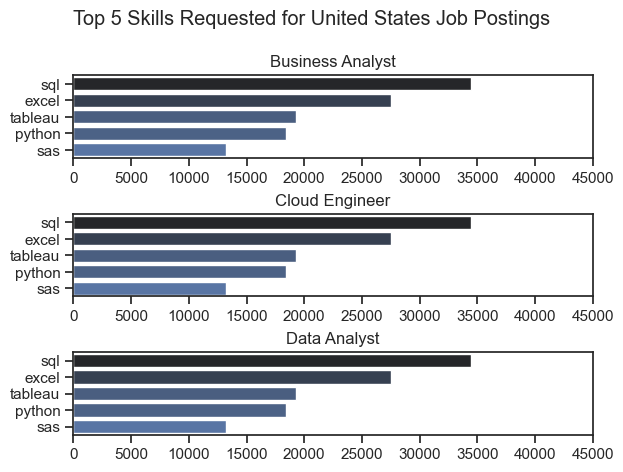

In [27]:
fig, ax = plt.subplots(len(job_titles),1)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_US_skills_count[df_US_skills_count['job_title_short'] == title].head(5)[::-1]
    sns.barplot(data=df_plot,x='skill_count', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 45000)
fig.suptitle('Top 5 Skills Requested for United States Job Postings')
fig.tight_layout(h_pad=0.5)
plt.show()

Turn Counts into Percentage
Focus: Counts don't show what portions of jobs are requesting these skills
So we'll convert the counts into percentages which helps us understand how each job title represents relative to the entire dataset.

Before we can calculate the percentages we need the total counts for the jobs posted by job title. Calculate the frequency of each job title using the value_counts() method on the job_title_short column. Then reset the index to transform the Series into a DataFrame and renames the columns to job_title_short and total. The DataFrame df_job_title_count now holds a list of job titles alongside their total occurrences.

In [32]:
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='job_total')
df_job_title_count

,job_title_short,job_total
0,Data Analyst,67816
1,Data Scientist,58830
2,Data Engineer,35080
3,Senior Data Scientist,12946
4,Senior Data Analyst,11791
5,Senior Data Engineer,9289
6,Business Analyst,7382
7,Software Engineer,1814
8,Machine Learning Engineer,921
9,Cloud Engineer,423


Then we calculate the percentages. First merge df_skills_count and df_job_title_count, based on the 'job_title_short' column, ensuring each skill count is associated with the total number of job postings for that title. Then calculate the percentage of each skill within its job title by dividing the skill count by the total job postings and multiplying by 100, adding this new data as a 'percentage' column.

In [33]:
df_skill_perc = df_US_skills_count.merge(df_job_title_count, on='job_title_short', how='left')
df_skill_perc['skill_percent'] = df_skill_perc['skill_count'] / df_skill_perc['job_total'] * 100
df_skill_perc

,job_title_short,job_skills,skill_count,job_total,skill_percent
0,Data Scientist,python,42379,58830,72.036376
1,Data Analyst,sql,34452,67816,50.802171
2,Data Scientist,sql,30034,58830,51.052184
3,Data Analyst,excel,27519,67816,40.578919
4,Data Scientist,r,26022,58830,44.232534
...,...,...,...,...,...
1865,Senior Data Engineer,asp.net core,1,9289,0.010765
1866,Cloud Engineer,ms access,1,423,0.236407
1867,Machine Learning Engineer,graphql,1,921,0.108578
1868,Senior Data Scientist,mariadb,1,12946,0.007724


Plot Percentage Count

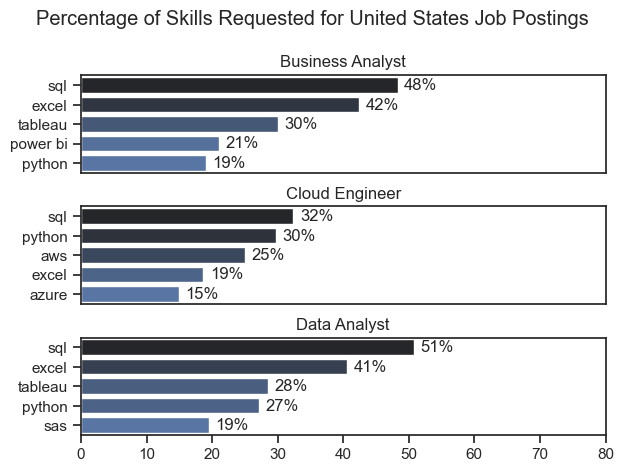

In [34]:
fig, ax = plt.subplots(len(job_titles),1)

sns.set_theme(style='ticks')
for i, job_title in enumerate(job_titles):
    df_plot = df_skill_perc[df_skill_perc['job_title_short'] == job_title].head(5)[::-1]
    sns.barplot(data=df_plot,x = 'skill_percent', y = 'job_skills', ax=ax[i], hue='skill_percent', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 80)
     # remove the x-axis tick labels for better readability
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    # label the percentage on the bars
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')
fig.suptitle('Percentage of Skills Requested for United States Job Postings')
fig.tight_layout(h_pad=0.8)
plt.show()